In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
load_dotenv()

llm = ChatOpenAI()

In [5]:
class JokeState(TypedDict):
    topic: str
    joke:str
    explanation:str

In [6]:
def generate_joke(state: JokeState):
    prompt= f'generate a joke on topic {state['topic']}'
    response = llm.invoke(prompt).content
    
    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):
    prompt= f'Explain the joke {state['joke']}'
    response = llm.invoke(prompt).content
    
    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)


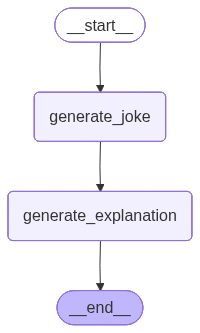

In [9]:
workflow

In [21]:
config1 = {"configurable":{"thread_id":"1"}}
initial_state = {'topic': 'imran khan'}
workflow.invoke(initial_state,config=config1)

{'topic': 'imran khan',
 'joke': 'Why did Imran Khan join a cooking class? \n\nBecause he heard it was the best way to "knead" peace in Pakistan!',
 'explanation': 'This joke is a play on words. "Knead" sounds like "need", so when it says that Imran Khan joined a cooking class because he heard it was the best way to "knead" peace in Pakistan, it is making a pun on the idea of needing (or kneading) something in order to achieve peace. Cooking classes involve kneading dough, so the joke is using the word play to suggest that Imran Khan believes that cooking (and kneading dough) is the key to achieving peace in Pakistan.'}

In [22]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'imran khan', 'joke': 'Why did Imran Khan join a cooking class? \n\nBecause he heard it was the best way to "knead" peace in Pakistan!', 'explanation': 'This joke is a play on words. "Knead" sounds like "need", so when it says that Imran Khan joined a cooking class because he heard it was the best way to "knead" peace in Pakistan, it is making a pun on the idea of needing (or kneading) something in order to achieve peace. Cooking classes involve kneading dough, so the joke is using the word play to suggest that Imran Khan believes that cooking (and kneading dough) is the key to achieving peace in Pakistan.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08c6b1-354e-666d-8022-bb2813fddc51'}}, metadata={'source': 'loop', 'step': 34, 'parents': {}}, created_at='2025-09-08T04:19:56.220580+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08c6b1-2832-630a-8021-89b2

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'imran khan', 'joke': 'Why did Imran Khan join a cooking class? \n\nBecause he heard it was the best way to "knead" peace in Pakistan!', 'explanation': 'This joke is a play on words. "Knead" sounds like "need", so when it says that Imran Khan joined a cooking class because he heard it was the best way to "knead" peace in Pakistan, it is making a pun on the idea of needing (or kneading) something in order to achieve peace. Cooking classes involve kneading dough, so the joke is using the word play to suggest that Imran Khan believes that cooking (and kneading dough) is the key to achieving peace in Pakistan.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08c6b1-354e-666d-8022-bb2813fddc51'}}, metadata={'source': 'loop', 'step': 34, 'parents': {}}, created_at='2025-09-08T04:19:56.220580+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08c6b1-2832-630a-8021-89b

In [24]:
config2 = {"configurable":{"thread_id":"2"}}
initial_state = {'topic': 'modi'}
workflow.invoke(initial_state,config=config2)

{'topic': 'modi',
 'joke': 'Why did Modi break up with his calculator? Because it always divided things instead of multiplying them!',
 'explanation': 'This joke plays on the idea that a calculator is supposed to help with multiplication (combining numbers to make a larger total), but in this case, the calculator only divides (splitting numbers into smaller portions). The punchline reveals that Modi broke up with his calculator because it was not fulfilling its intended purpose, which is meant to be humorous because calculators are typically seen as very straightforward and reliable tools.'}